In [3]:
import pandas as pd
import numpy as np
import math
import warnings

def addColumns(data):
    #Add Responders vs Non Responder:
    # Responders: CR/PR, Non responder: PD
    responderCrit = data['BR'].isin(['CR','PR'])
    progressorCrit = data['BR'].isin(['PD'])

    
    data["PD_Responders"] = "SD/MR"
    responders = data[responderCrit].index
    progressors = data[progressorCrit].index
    nonresponders = data[~responderCrit].index
    nonprogressors = data[~progressorCrit].index
    
    data.loc[responders,"PD_Responders"] = 'Responder'
    data.loc[progressors,"PD_Responders"] = 'Progressor'
    return data
                
seed = 42
syn_datas = ["original_data",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
dataset_dict = {}
for syn_data in syn_datas:
    print(f"-----{syn_data}-----")
    df = pd.read_csv(f"Data/{syn_data}.csv",index_col = 0)
    processed_df = addColumns(df)
    dataset_dict[syn_data] = processed_df

-----original_data-----
-----avatarsk10_42-----
-----ctgan_42-----
-----gaussiancopula_42-----
-----synthpop_42-----
-----tvae_42-----


In [99]:
import gseapy as gp

def load_gmt_as_dict(gmt_file):
    gene_sets = {}
    with open(gmt_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            set_name = parts[0]
            # parts[1] is description (often ignored)
            # Upper-case genes and remove any empty strings / duplicates
            genes = [g.strip().upper() for g in parts[2:] if g.strip()]
            # preserve order but remove duplicates
            seen = set()
            genes_unique = []
            for g in genes:
                if g not in seen:
                    seen.add(g)
                    genes_unique.append(g)
            gene_sets[set_name] = genes_unique
    return gene_sets

mhc_ii = [
    "HLA-DMA", "HLA-DMB", "HLA-DOA", "HLA-DOB", "HLA-DPA1", "HLA-DPB1",
    "HLA-DQA1", "HLA-DQA2", "HLA-DQB1", "HLA-DQB2", "HLA-DRA", "HLA-DRB1", "HLA-DRB5"
]
mhc_i = ["HLA-A", "HLA-B", "HLA-C", "HLA-E", "HLA-F", "TAP1", "TAP2", "B2M"]

hallmarks_gmt = "../PublicationData/h.all.v2025.1.Hs.symbols.gmt"
gmt_dict = load_gmt_as_dict(hallmarks_gmt)  # returns dict with upper-cased genes

# add custom sets as upper-cased lists
gmt_dict["MHC-II"] = [g.upper() for g in mhc_ii]
gmt_dict["MHC-I"] = [g.upper() for g in mhc_i]
ssGSEA = {}
genes_cols = data.columns.tolist()[54:-1]
for tool, data in dataset_dict.items():
    ssgsea_res = gp.ssgsea(
        data=data[genes_cols].T,
        gene_sets=gmt_dict,
        sample_norm_method='rank',
        outdir=None,
        permutation_num=0,
        no_plot=True,
        min_size=1,
        max_size=10000
    )
    res2d = ssgsea_res.res2d
    
    res_wide = res2d.pivot(index="Name", columns="Term", values="NES")
    res_wide.to_csv(f"ssGSEA/ssGSEA_{tool}_{seed}.csv", index = True)
    ssGSEA[tool] = res_wide

In [100]:
from scipy.stats import ranksums
from statsmodels.sandbox.stats.multicomp import multipletests
from tqdm import tqdm
from joblib import Parallel, delayed
import numpy as np
import pandas as pd

def ssGSEA_analysis(pathway_expressions, metadata, phenotypes, id_col, n_jobs=-1, verbose=0):
    """
    Differential analysis of ssGSEA scores between two phenotype groups.

    Returns a DataFrame with columns:
     - Term: pathway name
     - P_value: two-sided Wilcoxon rank-sum test p-value
     - MeanES_A: mean enrichment score in phenotype A
     - MeanES_B: mean enrichment score in phenotype B
     - MeanES_diff: MeanES_A - MeanES_B (difference in mean enrichment scores)
     - Status: semicolon-separated flags describing edge cases
     - Q_value: FDR-adjusted p-value (Benjamini-Hochberg)
     - Rank_Score: sign(MeanES_diff) * -log10(Q_value) (NaN if MeanES_diff or Q_value is NaN)
    """

    # Extract phenotype column and values (expect exactly two)
    ph_column, ph_values = next(iter(phenotypes.items()))
    if len(ph_values) != 2:
        raise ValueError(f"Phenotype values list must contain exactly two values, got: {ph_values}")

    phenotype_A, phenotype_B = ph_values

    phenotypeA_samples = metadata[metadata[ph_column] == phenotype_A][id_col].values.tolist()
    phenotypeB_samples = metadata[metadata[ph_column] == phenotype_B][id_col].values.tolist()

    if len(phenotypeA_samples) == 0 or len(phenotypeB_samples) == 0:
        raise ValueError("One of the phenotype groups has no samples.")

    # Subset expression table (rows = sample ids, columns = pathways)
    phenotypeA_DF = pathway_expressions.loc[phenotypeA_samples, :]
    phenotypeB_DF = pathway_expressions.loc[phenotypeB_samples, :]

    pathways = pathway_expressions.columns.tolist()

    def process_path(pathway):
        # Read series and coerce to numeric (non-numeric -> NaN)
        A_series = phenotypeA_DF[pathway]
        B_series = phenotypeB_DF[pathway]

        A_num = pd.to_numeric(A_series, errors='coerce').values
        B_num = pd.to_numeric(B_series, errors='coerce').values

        status = []

        # Check all-NaN or empty arrays
        if A_num.size == 0 or np.all(pd.isnull(A_num)):
            status.append("A_all_nan_or_empty")
        if B_num.size == 0 or np.all(pd.isnull(B_num)):
            status.append("B_all_nan_or_empty")

        # Remove NaNs
        cleaned_A_exp = A_num[~pd.isnull(A_num)]
        cleaned_B_exp = B_num[~pd.isnull(B_num)]

        # Compute p-value safely
        if cleaned_A_exp.size == 0 or cleaned_B_exp.size == 0:
            pvalue = np.nan
            status.append("No_data")
        else:
            # If both groups constant and equal -> p=1
            try:
                if np.all(cleaned_A_exp == cleaned_A_exp[0]) and np.all(cleaned_B_exp == cleaned_B_exp[0]) and cleaned_A_exp[0] == cleaned_B_exp[0]:
                    pvalue = 1.0
                    status.append("Identical")
                else:
                    _, pvalue = ranksums(cleaned_A_exp, cleaned_B_exp, alternative='two-sided')
                    if pd.isnull(pvalue):
                        status.append("p_nan")
            except Exception as e:
                pvalue = np.nan
                status.append(f"ranksums_error:{str(e)}")

        # Means (nan-safe)
        mean_A = np.nan if cleaned_A_exp.size == 0 else float(np.nanmean(cleaned_A_exp))
        mean_B = np.nan if cleaned_B_exp.size == 0 else float(np.nanmean(cleaned_B_exp))

        # Compute MeanES difference (MeanES_A - MeanES_B)
        if pd.isnull(mean_A) or pd.isnull(mean_B):
            mean_diff = np.nan
            status.append("meanES_nan")
        else:
            # Special cases / informative flags
            if mean_A == 0 and mean_B == 0:
                mean_diff = 0.0
                status.append("meanES_both_zero")
            else:
                mean_diff = mean_A - mean_B
                if mean_B == 0:
                    status.append("B_noExp")
                if mean_A == 0:
                    status.append("A_noExp")

        if not status:
            status = ["ok"]
        return pvalue, mean_A, mean_B, mean_diff, ";".join(status)

    # Parallel processing (tqdm over pathways to show progress)
    results = Parallel(n_jobs=n_jobs, verbose=verbose)(
        delayed(process_path)(pathway) for pathway in tqdm(pathways, desc="ssGSEA score differential analysis")
    )
    pvalues, meanAs, meanBs, meanDiffs, statusflags = zip(*results)

    results_df = pd.DataFrame(
        {
            "Term": pathways,
            "P_value": np.array(pvalues, dtype=float),
            "MeanNES_A": np.array(meanAs, dtype=float),
            "MeanNES_B": np.array(meanBs, dtype=float),
            "MeanNES_diff": np.array(meanDiffs, dtype=float),
            "Status": statusflags,
        }
    )

    # Multiple testing correction (handle all-NaN p-values)
    pvalues_arr = results_df["P_value"].to_numpy(dtype=float)
    valid_p_mask = ~pd.isnull(pvalues_arr)
    valid_pvalues = pvalues_arr[valid_p_mask]
    qvalues = np.full(pvalues_arr.shape, np.nan, dtype=float)
    if valid_pvalues.size > 0:
        _, qvals_valid, _, _ = multipletests(valid_pvalues, method='fdr_bh')
        qvalues[valid_p_mask] = qvals_valid

    results_df['Q_value'] = qvalues

    # Rank_Score: sign(MeanES_diff) * (-log10(Q_value)), protecting against Q_value == 0
    tiny = 1e-300
    q_arr = results_df["Q_value"].to_numpy()
    safe_q = np.where(np.isnan(q_arr), np.nan, np.maximum(q_arr, tiny))
    log_term = -np.log10(safe_q)

    rank_score = np.where(
        pd.isnull(results_df["MeanNES_diff"].to_numpy()) | pd.isnull(results_df["Q_value"].to_numpy()),
        np.nan,
        (results_df["MeanNES_diff"].to_numpy()) * log_term
    )
    results_df["Rank_Score"] = rank_score # https://doi.org/10.1093/bioinformatics/btr671

    return results_df

In [101]:
ssGSEA_results = {}
for name, data in dataset_dict.items():
    print(f"----ssGSEA Analysis {name} ----")
    # genelist = data.columns.tolist()[54:-1]
    metadata = pd.DataFrame(
        {"Patient": data.index,
        "PD_Responders": data["PD_Responders"].values.tolist()}
    )
    pathway_expressions = ssGSEA[name]
    id_col = "Patient"
    phenotypes = {"PD_Responders": ["Responder","Progressor"]}
    ssGSEA_df = ssGSEA_analysis(pathway_expressions, metadata, phenotypes, id_col, n_jobs=-1, verbose=0)
    # degs_df.to_csv(f"DEGs/DEGs_{name}_{seed}.csv", index = False)
    ssGSEA_results[name] = ssGSEA_df

----ssGSEA Analysis original_data ----


ssGSEA score differential analysis: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 52/52 [00:00<00:00, 721.67it/s]


----ssGSEA Analysis avatarsk10_42 ----


ssGSEA score differential analysis: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 52/52 [00:00<00:00, 749.83it/s]


----ssGSEA Analysis ctgan_42 ----


...

ssGSEA score differential analysis: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 52/52 [00:00<00:00, 844.49it/s]


----ssGSEA Analysis synthpop_42 ----


ssGSEA score differential analysis: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 52/52 [00:00<00:00, 830.37it/s]


----ssGSEA Analysis tvae_42 ----


ssGSEA score differential analysis: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 52/52 [00:00<00:00, 655.59it/s]


In [50]:
from collections import Iterable
from typing import Dict, Optional, Tuple, Any, List

def _to_set(pathways: Iterable[Any], case_sensitive: bool = False) -> set:
    if pathways is None:
        return set()
    if not case_sensitive:
        return {str(x).strip().lower() for x in pathways if pd.notna(x)}
    else:
        return {str(x).strip() for x in pathways if pd.notna(x)}


def compute_jaccard_indices(
    original_pathways: Iterable[Any],
    synth_pathways_dict: Dict[str, Iterable[Any]],
    case_sensitive: bool = False,
) -> pd.DataFrame:
    """
    The Jaccard index is defined as:
        J(A, B) = |A ∩ B| / |A ∪ B|
    """
    if not isinstance(synth_pathways_dict, dict):
        raise ValueError("synth_pathways_dict must be a dict mapping dataset name -> iterable of pathways")

    A = _to_set(original_pathways, case_sensitive=case_sensitive)
    rows = []
    for ds_name, synth_paths in synth_pathways_dict.items():
        B = _to_set(synth_paths, case_sensitive=case_sensitive)
        inter = A.intersection(B)
        union = A.union(B)
        inter_size = len(inter)
        union_size = len(union)

        if union_size == 0:
            # both sets empty -> identical
            j = 1.0
        else:
            j = inter_size / union_size

        rows.append(
            {
                "Dataset": ds_name,
                "Original_count": len(A),
                "Synthetic_count": len(B),
                "Intersection": inter_size,
                "Union": union_size,
                "Jaccard": j,
            }
        )

    df = pd.DataFrame(rows, columns=["Dataset", "Original_count", "Synthetic_count", "Intersection", "Union", "Jaccard"])
    return df


def extract_significant_pathways(
    df: pd.DataFrame,
    term_col: str = "Term",
    adj_p_col: str = "P_value",
    threshold: float = 0.05,
) -> List[str]:
    if df is None or df.empty:
        return []
    if term_col not in df.columns or adj_p_col not in df.columns:
        return []
    sub = df[df[adj_p_col].astype(float) < float(threshold)].copy()
    # drop NA/empty terms and return list
    sub = sub[sub[term_col].notna()]
    return [str(x).strip() for x in sub[term_col].tolist()]

In [103]:
orig_paths = extract_significant_pathways(ssGSEA_results["original_data"], term_col="Term", adj_p_col="P_value", threshold=0.05)
synth_paths_dict = {k: extract_significant_pathways(v, term_col="Term", adj_p_col="P_value", threshold=0.05)
                     for k, v in ssGSEA_results.items() if k != "original_data"}
jaccard_df = compute_jaccard_indices(orig_paths, synth_paths_dict)
jaccard_df.to_csv(f"ssGSEA/JaccardIndex_{seed}.csv", index = False)
jaccard_df

,Dataset,Original_count,Synthetic_count,Intersection,Union,Jaccard
0,avatarsk10_42,7,25,5,27,0.185185
1,ctgan_42,7,1,0,8,0.000000
2,gaussiancopula_42,7,2,2,7,0.285714
3,synthpop_42,7,7,2,12,0.166667
4,tvae_42,7,9,1,15,0.066667


In [104]:
from scipy.stats import spearmanr
GSEA_list = []
for name, df in ssGSEA_results.items():
    df["Dataset"] = name
    GSEA_list.append(df)
GSEA_df = pd.concat(GSEA_list, axis = 0)
pivot_df = GSEA_df.pivot_table(
    index="Term",
    columns="Dataset",
    values="Rank_Score"
)


origin_values = pivot_df["original_data"]

results = []

for dataset in pivot_df.columns:
    if dataset == "original_data":
        continue  # skip comparison with itself
    
    x = origin_values
    y = pivot_df[dataset]

    # Drop rows where either side is NaN
    valid = ~(x.isna() | y.isna())
    rho, pval = spearmanr(x[valid], y[valid])

    results.append({
        "Dataset": dataset,
        "Spearman_rho": rho,
        "p_value": pval,
        "n_terms_used": valid.sum()
    })

# Convert results to DataFrame
spearman_df = pd.DataFrame(results)
# spearman_df.to_csv(f"ssGSEA/Spearman_df{seed}.csv", index = False)
spearman_df

,Dataset,Spearman_rho,p_value,n_terms_used
0,avatarsk10_42,0.618543,1.024594e-06,52
1,ctgan_42,-0.121147,3.922592e-01,52
2,gaussiancopula_42,0.732690,6.634675e-10,52
3,synthpop_42,0.436950,1.200422e-03,52
4,tvae_42,0.528729,5.593292e-05,52


In [55]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import seaborn as sns
def plot_jaccard_vs_spearman(
    jaccard_df: pd.DataFrame,
    spearman_df: pd.DataFrame,
    dataset_col: str = "Dataset",
    jaccard_col: str = "Jaccard",
    spearman_col: str = "Spearman_rho",
    size_col: Optional[str] = "Synthetic_count",
    annotate: bool = True,
    figsize: Tuple[float, float] = (8, 6),
    savepath: Optional[str] = None,
    title: Optional[str] = "Jaccard index vs Spearman rho",
) -> Tuple[plt.Figure, plt.Axes]:
    # Validate inputs
    if dataset_col not in jaccard_df.columns:
        raise ValueError(f"{dataset_col} not found in jaccard_df")
    if dataset_col not in spearman_df.columns:
        raise ValueError(f"{dataset_col} not found in spearman_df")
    if jaccard_col not in jaccard_df.columns:
        raise ValueError(f"{jaccard_col} not found in jaccard_df")
    if spearman_col not in spearman_df.columns:
        raise ValueError(f"{spearman_col} not found in spearman_df")

    # Merge on dataset
    df = pd.merge(
        spearman_df,
        jaccard_df,
        on=dataset_col,
        how="outer",
        suffixes=("_spearman", "_jaccard"),
    )

    # Prepare columns
    df = df.rename(columns={jaccard_col: "Jaccard", spearman_col: "Spearman_rho"})
    # If user requested size_col but it has different name in jaccard_df, try to keep as-is
    if size_col is not None and size_col not in df.columns:
        # fall back to n_terms_used or Synthetic_count if available
        if "n_terms_used" in df.columns:
            size_col = "n_terms_used"
        elif "Synthetic_count" in df.columns:
            size_col = "Synthetic_count"
        else:
            size_col = None

    # Drop rows that do not have both metrics (can't plot)
    plot_df = df.loc[df["Jaccard"].notna() & df["Spearman_rho"].notna()].copy()

    # If no rows to plot, create empty figure with message
    if plot_df.shape[0] == 0:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "No datasets with both Jaccard and Spearman available", ha="center", va="center")
        ax.axis("off")
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        return fig, ax

    # # Compute Spearman correlation between Jaccard and Spearman_rho (on available rows)
    # rho, pval = spearmanr(plot_df["Jaccard"], plot_df["Spearman_rho"], nan_policy="omit")

    # Determine point sizes
    if size_col is not None:
        # scale sizes to a reasonable range
        raw_sizes = plot_df[size_col].fillna(0).astype(float)
        # map zero -> small, others scaled
        min_size = 50
        max_size = 450
        if raw_sizes.max() == raw_sizes.min():
            sizes = np.full(len(raw_sizes), (min_size + max_size) / 2.0)
        else:
            sizes = min_size + (raw_sizes - raw_sizes.min()) / (raw_sizes.max() - raw_sizes.min()) * (max_size - min_size)
    else:
        sizes = 120

    # Create plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        x=plot_df["Jaccard"],
        y=plot_df["Spearman_rho"],
        s=sizes,
        c="tab:blue",
        edgecolor="k",
        alpha=0.85,
        linewidth=0.6,
        zorder=3,
    )


    # Annotate each point with dataset name if requested (with small offset)
    if annotate:
        for _, row in plot_df.iterrows():
            dx = 0.005 * (ax.get_xlim()[1] - ax.get_xlim()[0])  # small fraction of x-range
            dy = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])  # small fraction of y-range
            ax.text(
                row["Jaccard"] + dx,
                row["Spearman_rho"] + dy,
                str(row[dataset_col]),
                fontsize=8,
                verticalalignment="bottom",
                horizontalalignment="left",
            )

    # Labels, title, legend, annotation for correlation
    ax.set_xlabel("Jaccard index", fontsize=11)
    ax.set_ylabel("Spearman rho", fontsize=11)
    ax.set_title(title, fontsize=12)



    # A grid and tight layout
    ax.grid(alpha=0.4, linestyle="--")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, ax

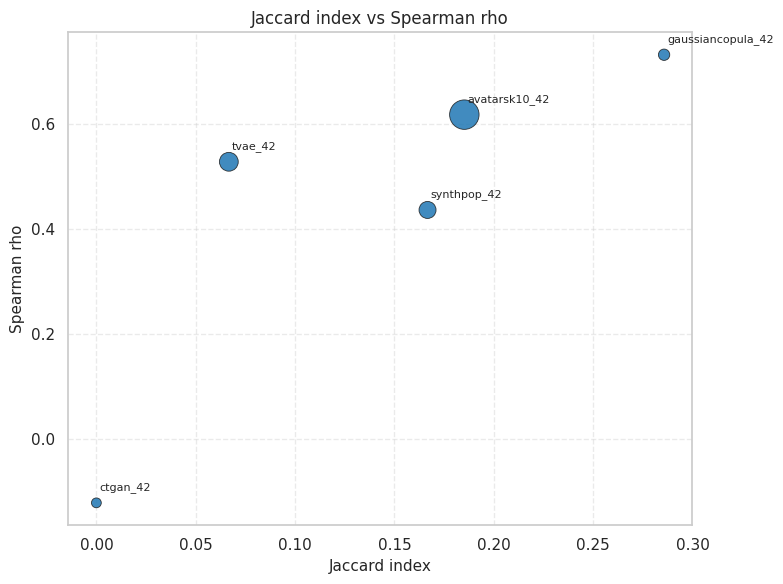

In [106]:
fig, ax = plot_jaccard_vs_spearman(jaccard_df, spearman_df, 
                                   size_col="Synthetic_count", annotate=True, savepath=f"ssGSEA/JaccardIndex_Spearman_{seed}.png")
plt.show()

In [61]:
from typing import List, Optional, Any, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_pathway_df(
    df: pd.DataFrame,
    ref_pathway_list: List[str],
    x_col: str = "NES_diff",
    y_col: str = "Term",
    p_value_col: str = "p_values",
    color_col: Optional[str] = None,
    highlight_pathways: Optional[List[str]] = None,
    order_by: Optional[str] = None,
    p_threshold: float = 0.05,
    cmap: Optional[Any] = None,
    fig_width_min: float = 10.0,
    marker_size: float = 100.0,   # fixed marker size (no scaling)
    show: bool = True,
    title: str = "Pathway bubble plot",
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
    eps: float = 1e-9,  # small epsilon added to p-values before -log10
) -> Tuple[plt.Figure, Optional[pd.DataFrame]]:


    if df is None or df.empty:
        raise ValueError("Input DataFrame `df` is empty or None.")
    if not ref_pathway_list:
        raise ValueError("`ref_pathway_list` must not be empty.")
    if y_col not in df.columns:
        raise ValueError(f"y_col '{y_col}' not found in DataFrame columns.")

    if cmap is None:
        cmap = plt.cm.plasma_r

    df = df.copy()

    # Coerce numeric columns safely
    if p_value_col in df.columns:
        df[p_value_col] = pd.to_numeric(df[p_value_col], errors="coerce")
    if x_col in df.columns:
        df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    else:
        df[x_col] = np.nan

    if color_col is not None and color_col in df.columns:
        # try to coerce numeric color columns; leave categorical as-is
        df[color_col] = pd.to_numeric(df[color_col], errors="coerce").fillna(df[color_col])

    # Compute -log10(p) helper (with eps) if p-values exist
    if p_value_col in df.columns:
        p_series = df[p_value_col].fillna(1.0).astype(float)
        p_series_clipped = p_series.clip(lower=eps)
        df["_log10_pvalue_helper"] = -np.log10(p_series_clipped)
    else:
        df["_log10_pvalue_helper"] = np.nan

    # Filter to reference pathways (ensure string matching)
    df[y_col] = df[y_col].astype(str)
    df_plot = df[df[y_col].isin([str(x) for x in ref_pathway_list])].copy()

    if df_plot.empty:
        fig = plt.figure(figsize=(8, 3))
        ax = fig.add_subplot(111)
        ax.text(0.5, 0.5, "No data to plot for the provided reference pathways.", ha="center", va="center", fontsize=12)
        ax.axis("off")
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        if show:
            plt.show()
        return (fig, pd.DataFrame([])) if return_dataframe else (fig, None)

    # Determine ordering of y labels
    present_pathways = list(df_plot[y_col].unique())
    if order_by and order_by in df_plot.columns:
        order_series = pd.to_numeric(df_plot[order_by], errors="coerce")
        order_df = df_plot[[y_col, order_by]].copy()
        order_df[order_by] = order_series
        order_df = order_df.dropna(subset=[order_by]).drop_duplicates(subset=[y_col])
        order_df = order_df.sort_values(by=order_by, ascending=True)
        sorted_pathways = [p for p in order_df[y_col].tolist() if p in ref_pathway_list]
        for p in ref_pathway_list:
            if p not in sorted_pathways and p in present_pathways:
                sorted_pathways.append(p)
    else:
        sorted_pathways = [p for p in ref_pathway_list if p in present_pathways]

    if not sorted_pathways:
        sorted_pathways = sorted(present_pathways)

    # Final y labels (reverse for top-to-bottom plotting)
    y_labels = [str(p) for p in sorted_pathways[::-1]]
    mapping = {p: idx for idx, p in enumerate(y_labels)}
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))

    # Choose color column
    color_col_use = color_col if color_col is not None else "_log10_pvalue_helper"
    if color_col_use not in df_plot.columns:
        raise ValueError(f"color column '{color_col_use}' not found in filtered DataFrame.")

    # Extract plotting arrays
    x_plot = pd.to_numeric(df_plot[x_col], errors="coerce").values
    y_plot = df_plot["y"].values

    color_series = df_plot[color_col_use]
    if pd.api.types.is_numeric_dtype(color_series):
        color_plot = color_series.astype(float).values
    else:
        # map categorical colors to integer codes
        categories = pd.Categorical(color_series)
        color_plot = categories.codes.astype(float)

    # Use fixed marker size for all points
    size_norm = np.full(shape=len(df_plot), fill_value=float(marker_size))

    # Normalize color
    if color_col_use == "_log10_pvalue_helper":
        norm_color_min = -np.log10(p_threshold + eps)
        color_max = np.nanmax(color_plot)
        if np.isnan(color_max) or color_max < (norm_color_min + 0.1):
            color_max = norm_color_min + 1.0
        norm = Normalize(vmin=norm_color_min, vmax=color_max)
        cbar_label = "$-\\log_{10}(p)$"
    else:
        finite_color = color_plot[np.isfinite(color_plot)]
        if finite_color.size == 0:
            norm = Normalize(vmin=0, vmax=1)
        else:
            norm = Normalize(vmin=np.nanmin(finite_color), vmax=np.nanmax(finite_color))
        cbar_label = color_col_use

    # Create figure
    FIG_WIDTH = max(fig_width_min, 10.0)
    FIG_HEIGHT = max(0.6 * len(y_labels) + 2, 6)
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

    sc = ax.scatter(
        x=x_plot,
        y=y_plot,
        s=size_norm,
        c=color_plot,
        cmap=cmap,
        norm=norm,
        edgecolor="k",
        linewidths=0.4,
        alpha=0.9,
        zorder=3,
    )

    # vertical line at 0 if numeric x
    if np.any(np.isfinite(x_plot)):
        max_abs_x = np.nanmax(np.abs(x_plot[np.isfinite(x_plot)]))
        ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
        ax.set_xlim(-max_abs_x * 1.05, max_abs_x * 1.05)
    else:
        ax.set_xlim(-1, 1)

    # Ensure ticks and labels are visible
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_ylim(len(y_labels) - 0.5, -0.5)
    ax.invert_yaxis()
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")

    # Highlight pathways on y-axis labels
    if highlight_pathways is None:
        highlight_pathways = []
    highlight_set = set(str(x) for x in highlight_pathways)
    for label in ax.get_yticklabels():
        pathway_name = label.get_text()
        if pathway_name in highlight_set:
            label.set_color("red")
            label.set_fontweight("bold")
        else:
            label.set_color("black")

    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="8%", pad=0.05)
    cbar = plt.colorbar(sc, cax=cax)
    cbar.set_label(cbar_label, fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    # Make room for y-labels if they are long
    plt.subplots_adjust(left=0.30, right=0.88, top=0.95, bottom=0.08)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    # attach mapping y positions to df_plot for downstream usage
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))

    return (fig, df_plot) if return_dataframe else (fig, None)

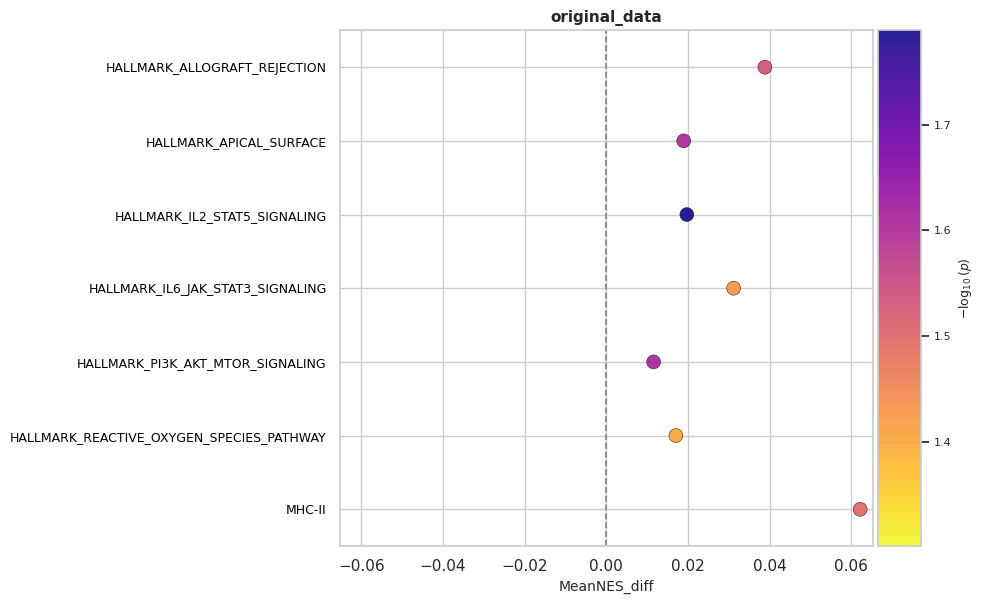

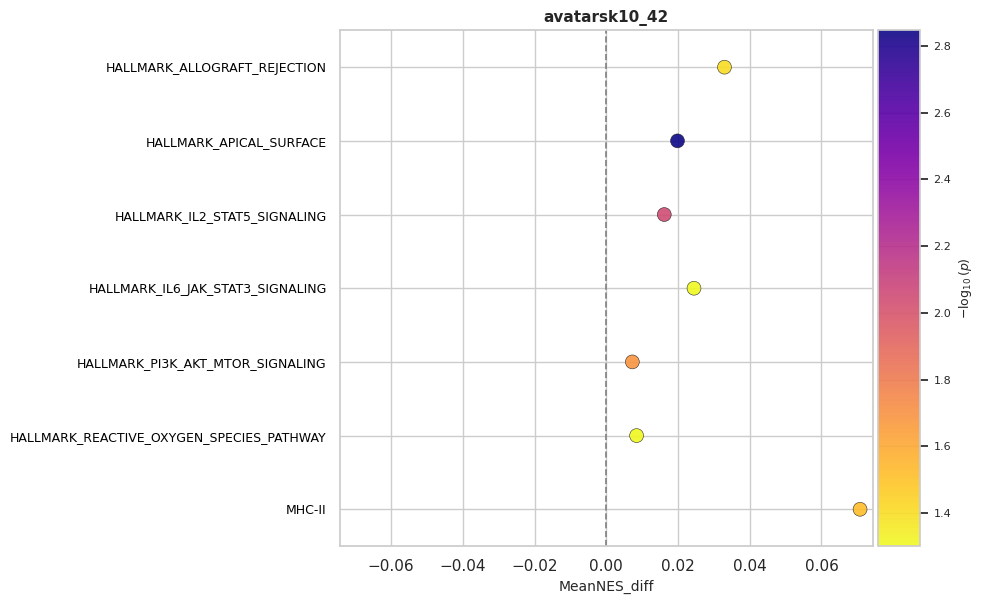

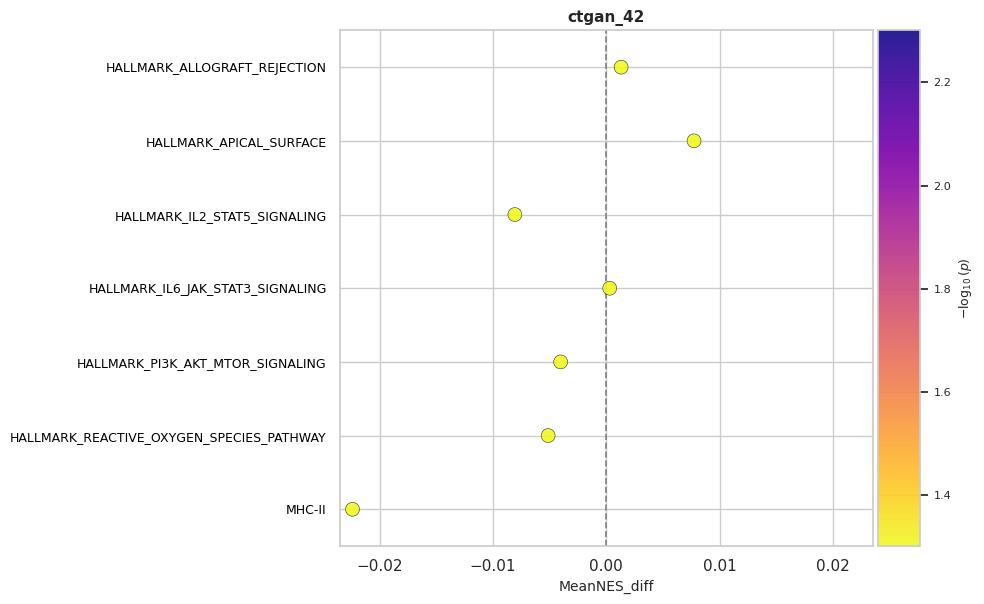

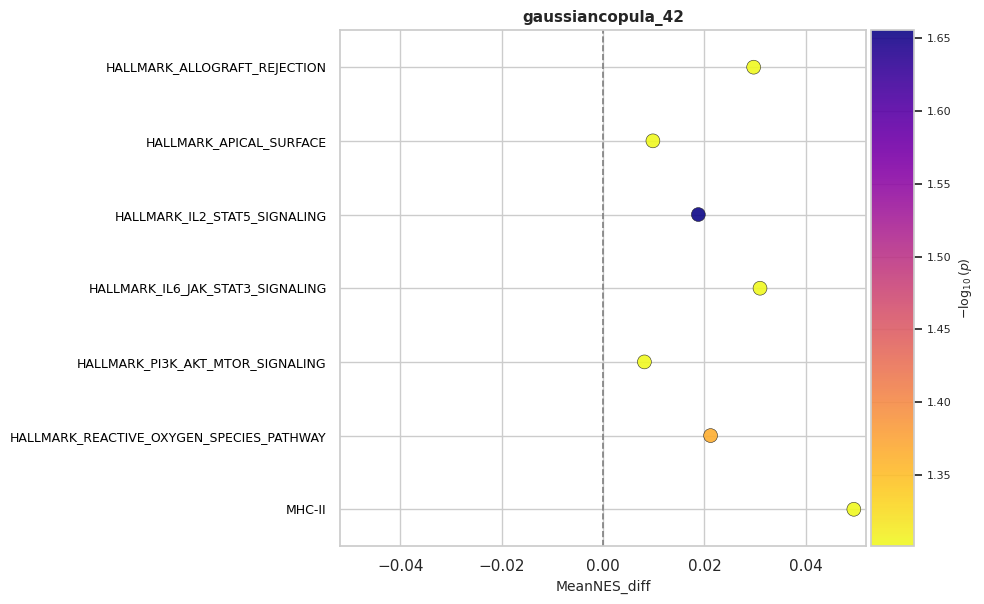

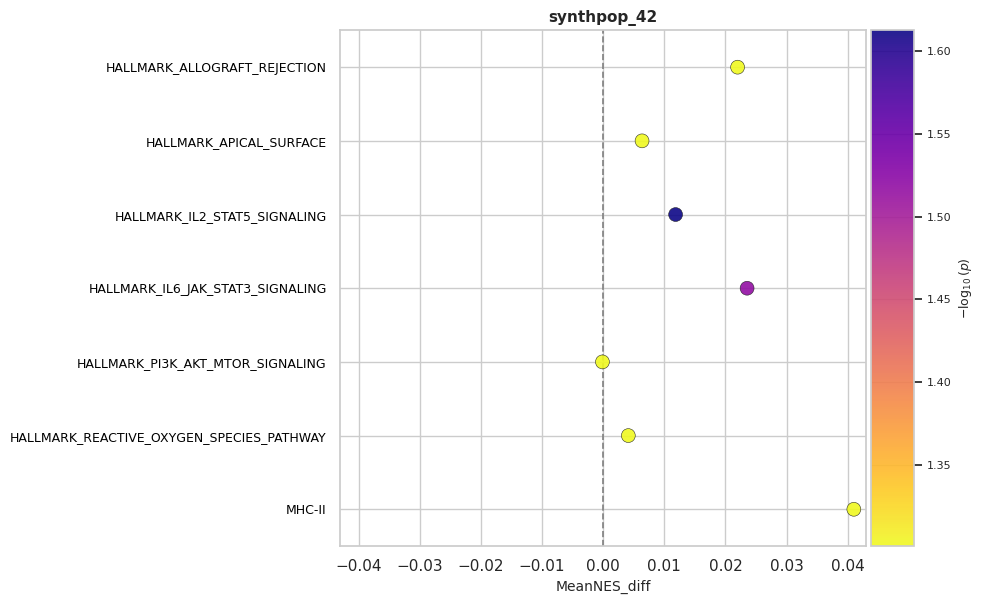

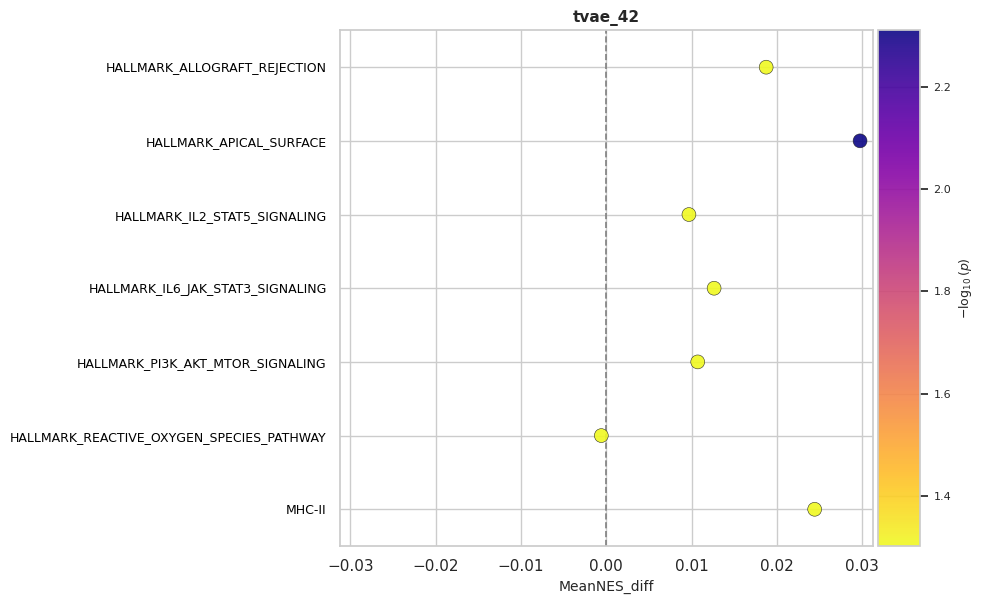

In [108]:
# Example usage:
for tool, ssGSEA_df in ssGSEA_results.items():
    fig, df_out = plot_pathway_df(ssGSEA_df, ref_pathway_list=orig_paths, x_col="MeanNES_diff", y_col="Term",
                                  p_value_col="P_value", highlight_pathways=None, title = f"{tool}",
                                    save_path =f"ssGSEA/BubblePlot_{tool}_{seed}.png", 
                                   color_col=None, order_by=None)

## **Difference of MHCII between CTLA4 subgroups**

In [111]:
ssGSEA_ctla4 = {}
genes_cols = data.columns.tolist()[54:-1]
for tool, data in dataset_dict.items():
    ssgsea_res = gp.ssgsea(
        data=data[genes_cols].T,
        gene_sets=gmt_dict,
        sample_norm_method='rank',
        outdir=None,
        permutation_num=0,
        no_plot=True,
        min_size=1,
        max_size=10000
    )
    res2d = ssgsea_res.res2d
    
    res_wide = res2d.pivot(index="Name", columns="Term", values="ES")
    # res_wide.to_csv(f"ssGSEA/ssGSEA_{tool}_{seed}.csv", index = True)
    ssGSEA_ctla4[tool] = res_wide

In [112]:
from scipy.stats import mannwhitneyu
for tool, df in dataset_dict.items():
    print(f"----{tool}----")
    res2d = ssGSEA_ctla4[tool]
    # res_wide = res2d.pivot(index="Name", columns="Term", values="ES")
    fullDF_ssGSEA = pd.concat([df,res2d["MHC-II"]], axis = 1)
    
    #Overall:
    # overallIP_df = fullDF_ssGSEA[fullDF_ssGSEA["IpiTreated"]==1]
    responders_df = fullDF_ssGSEA[fullDF_ssGSEA["PD_Responders"]=="Responder"]
    progressor_df = fullDF_ssGSEA[fullDF_ssGSEA["PD_Responders"]=="Progressor"]
    
    mhcii_score_responders = responders_df["MHC-II"].values.tolist()
    mhcii_score_progressor = progressor_df["MHC-II"].values.tolist()
    print("---Overall---")
    coff, pvalue = mannwhitneyu(mhcii_score_responders, mhcii_score_progressor,alternative = "two-sided")
    print(f"{len(mhcii_score_responders)} Responders: Mean {np.mean(mhcii_score_responders)}")
    print(f"{len(mhcii_score_progressor)} Progressor:  Mean {np.mean(mhcii_score_progressor)}")
    print(f" P-value: {pvalue}")
    
    #PostIP:
    postIP_df = fullDF_ssGSEA[fullDF_ssGSEA["daysBiopsyAfterIpiStart"]=="postIpi"]
    responders_df = postIP_df[postIP_df["PD_Responders"]=="Responder"]
    progressor_df = postIP_df[postIP_df["PD_Responders"]=="Progressor"]
    mhcii_score_responders = responders_df["MHC-II"].values.tolist()
    mhcii_score_progressor = progressor_df["MHC-II"].values.tolist()
    print("---Ipi-Experience---")
    coff, pvalue = mannwhitneyu(mhcii_score_responders, mhcii_score_progressor,alternative = "two-sided")
    print(f"{len(mhcii_score_responders)} Responders: Mean {np.mean(mhcii_score_responders)}")
    print(f"{len(mhcii_score_progressor)} Progressor:  Mean {np.mean(mhcii_score_progressor)}")
    print(f" P-value: {pvalue}")
    
    #IpiNaive
    naiveIP_df = fullDF_ssGSEA[fullDF_ssGSEA["daysBiopsyAfterIpiStart"]=="noIpi"]
    responders_df = naiveIP_df[naiveIP_df["PD_Responders"]=="Responder"]
    progressor_df = naiveIP_df[naiveIP_df["PD_Responders"]=="Progressor"]
    
    mhcii_score_responders = responders_df["MHC-II"].values.tolist()
    mhcii_score_progressor = progressor_df["MHC-II"].values.tolist()
    print("---Ipi-Naive---")
    coff, pvalue = mannwhitneyu(mhcii_score_responders, mhcii_score_progressor,alternative = "two-sided")
    print(f"{len(mhcii_score_responders)} Responders: Mean {np.mean(mhcii_score_responders)}")
    print(f"{len(mhcii_score_progressor)} Progressor:  Mean {np.mean(mhcii_score_progressor)}")
    print(f" P-value: {pvalue}")

----original_data----
---Overall---
47 Responders: Mean 4491.7947552174965
56 Progressor:  Mean 3756.354665327946
 P-value: 0.03219910649842801
---Ipi-Experience---
11 Responders: Mean 5395.662030107181
16 Progressor:  Mean 4342.34143699476
 P-value: 0.05127370614904813
---Ipi-Naive---
31 Responders: Mean 4183.75695958355
34 Progressor:  Mean 3684.2827923032887
 P-value: 0.23458503674493691
----avatarsk10_42----
---Overall---
45 Responders: Mean 4892.17714071074
52 Progressor:  Mean 4093.315683782353
 P-value: 0.0302700336674616
---Ipi-Experience---
10 Responders: Mean 5710.292893847142
23 Progressor:  Mean 4360.778602468378
 P-value: 0.05249338145764558
---Ipi-Naive---
35 Responders: Mean 4658.4297826717675
25 Progressor:  Mean 3708.606956609231
 P-value: 0.03450038204247294
----ctgan_42----
---Overall---
41 Responders: Mean 4251.617895253034
52 Progressor:  Mean 4477.777694892785
 P-value: 0.2803818857851963
---Ipi-Experience---
10 Responders: Mean 4336.648747467289
15 Progressor:  M

In [145]:
def PlotStackedBarPlot(barPlot, df_nonnorm, colorList, sigOrder = None, xlabel = False, normalize = False, legendSize = 50):
    numSamples = len(df_nonnorm.columns)
    numClasses = len(df_nonnorm)

#    plt.figure(figsize=(30,10))

    if normalize: 
        # normalize data
        df = df_nonnorm/df_nonnorm.apply(sum, axis = 0)
    else:
        df = df_nonnorm

    # set order
    if sigOrder is None: # set signature order to default order
        sigOrder = df_nonnorm.index    
    df = df.loc[sigOrder]
    
    # generate the bottoms of each of the stacked values
    bottom = [np.array([0] * numSamples)]
    for i in range(0, numClasses):
        bottom.append(bottom[i] + np.array(df.iloc[i,:]))
    
    ind = np.arange(numSamples)
    width = 0.5
    bargraphs = []
    
    for i in range(0, numClasses):
        bargraphs.append(plt.bar(ind, df.iloc[i,:], width, bottom = bottom[i], color = colorList[i+1]))

    # label x axis
    if xlabel:
        plt.setp(barPlot.get_xticklabels(), visible=True)
        plt.xticks(ind, df.columns, rotation = 'vertical')
#        barPlot.get_xaxis().set_ticks(ind + width/2., df.columns, rotation = 'vertical')
    else:
        plt.setp(barPlot.get_xticklabels(), visible=False)

    # Limit x axis
    plt.xlim(-0.5, numSamples-0.5)
        
#        barPlot.get_xaxis().set_ticks(ind + width/2., [])
    
    # label y axis
    barPlot.get_yaxis().set_label("Mutations")
    
    
    # Legend
    if legendSize is not None:
        barPlot.legend([x[0] for x in bargraphs[::-1]], sigOrder[::-1], prop = {'size':legendSize}, 
                        bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

0
             High  Low
Responders     28   19
Progressors    23   33
[[28, 19], [23, 33]]
MHC-II R vs. PD: p = 0.07617490311145005 (Fisher)
MHC-II R vs. PD: OR =  2.11441647597254
1
             High  Low
Responders      9    2
Progressors     7    9
[[9, 2], [7, 9]]
Ipi-Exp MHC-II R vs. PD: p = 0.10902319737963835 (Fisher)
Ipi-Exp MHC-II R vs. PD: OR =  5.785714285714286
2
             High  Low
Responders     17   14
Progressors    15   19
[[17, 14], [15, 19]]
Ipi-Naive MHC-II R vs. PD: p = 0.4602970190306581 (Fisher)
Ipi-Naive MHC-II R vs. PD: OR =  1.5380952380952382
0
             High  Low
Responders     27   18
Progressors    19   33
[[27, 18], [19, 33]]
MHC-II R vs. PD: p = 0.025825564506462513 (Fisher)
MHC-II R vs. PD: OR =  2.6052631578947367
1
             High  Low
Responders      8    2
Progressors     9   14
[[8, 2], [9, 14]]
Ipi-Exp MHC-II R vs. PD: p = 0.057026325546903976 (Fisher)
Ipi-Exp MHC-II R vs. PD: OR =  6.222222222222222
2
             High  Low
Responders   

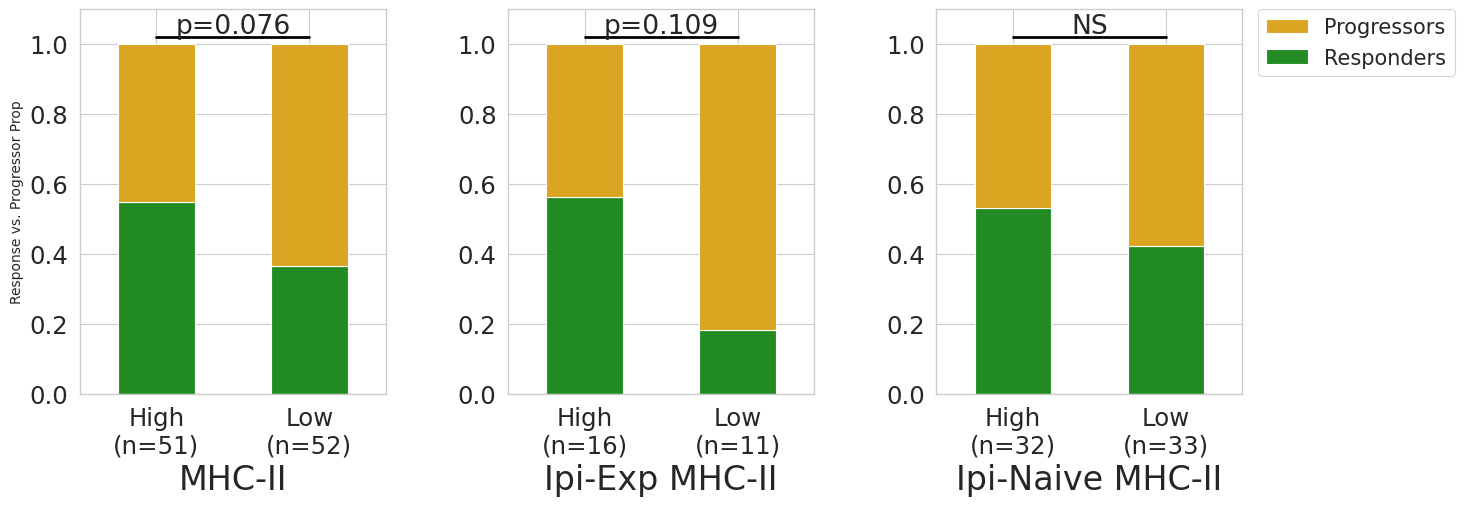

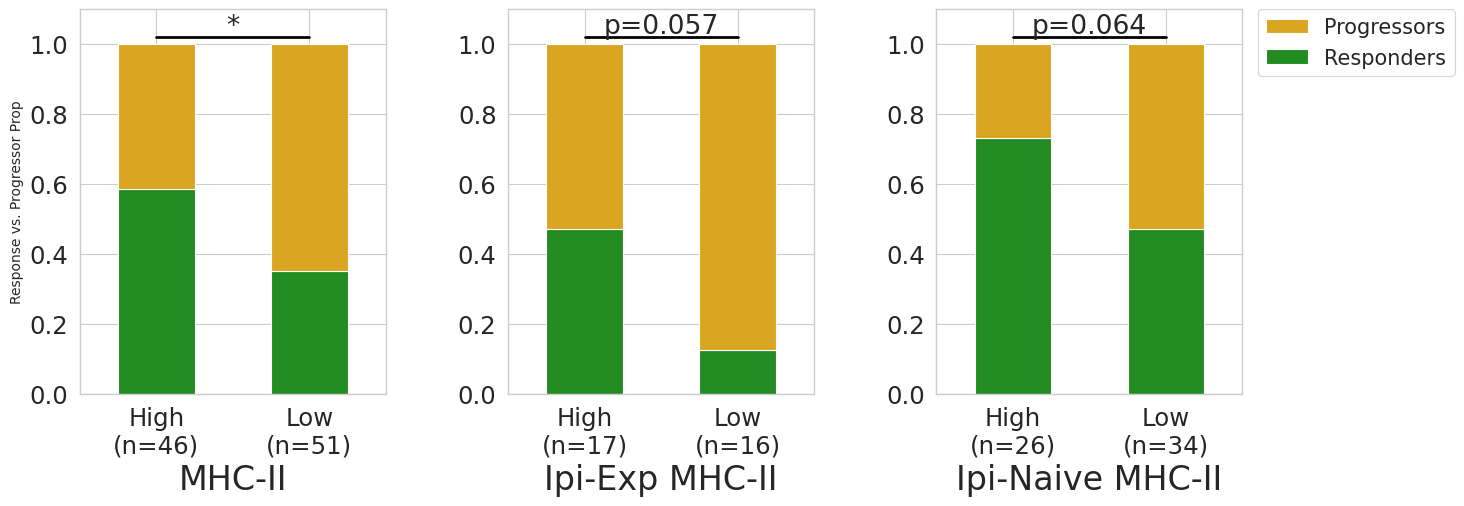

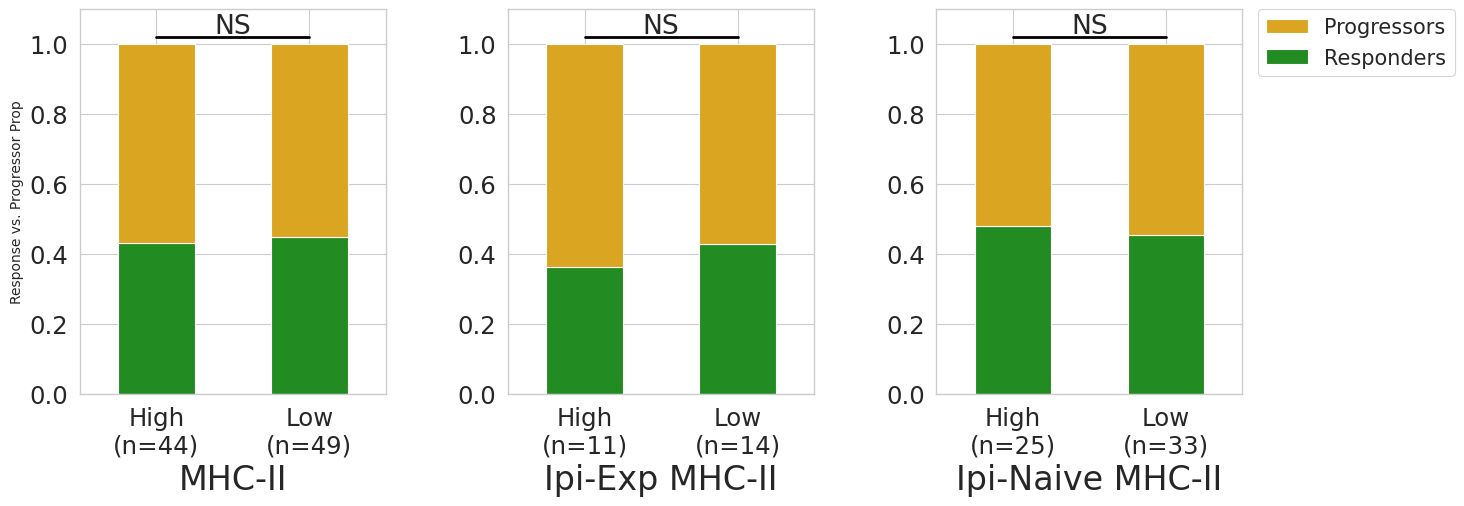

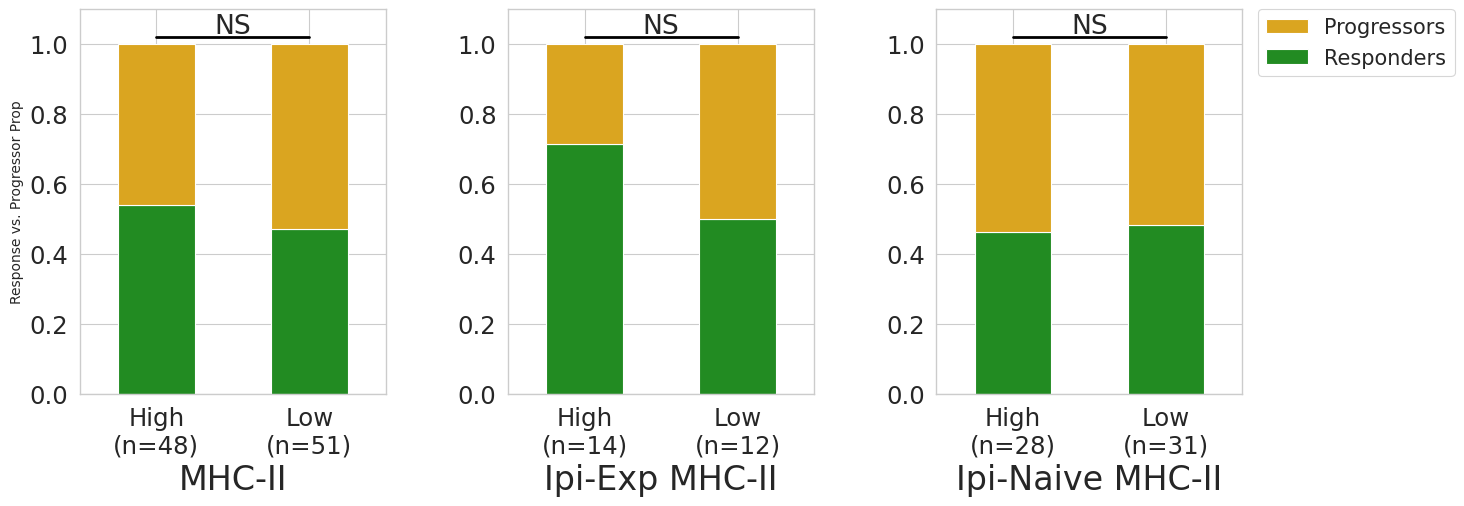

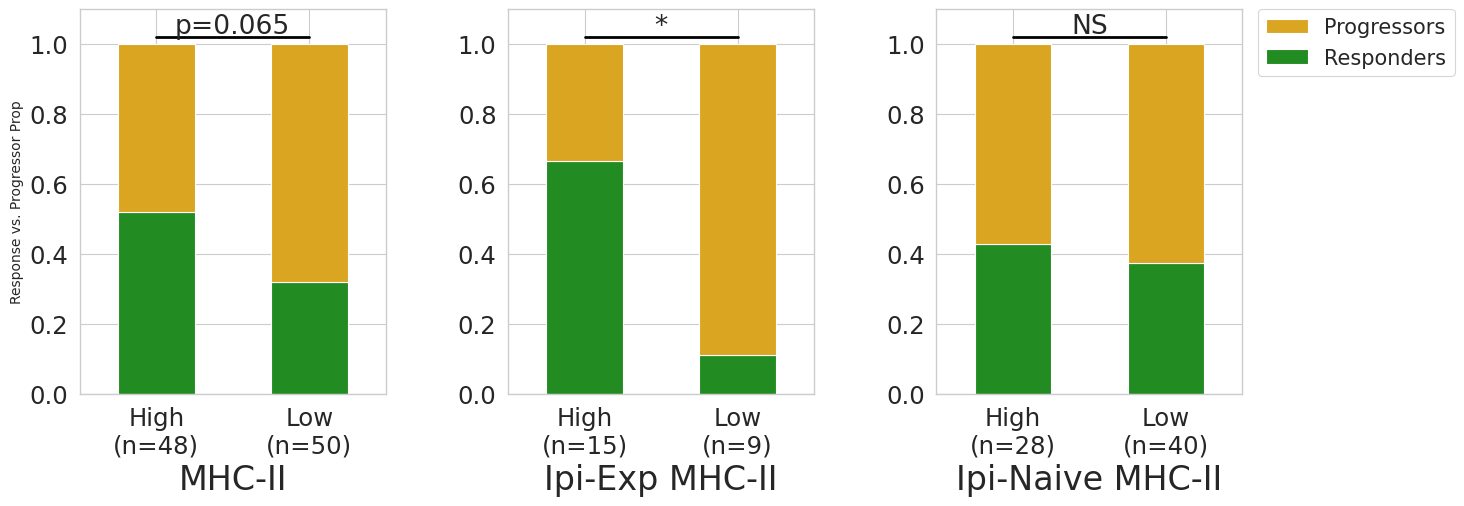

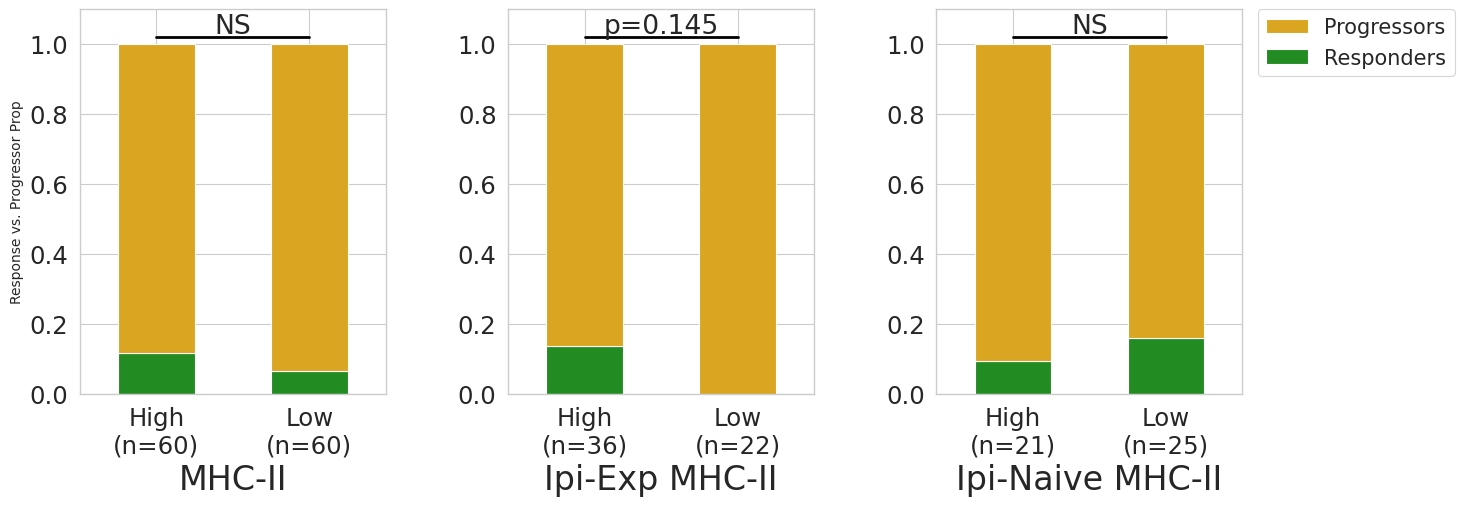

In [147]:
import matplotlib.gridspec as gridspec
for tool in dataset_dict.keys():
    # tool = 'original_data'
    res2d = ssGSEA_ctla4[tool]
    # res_wide = res2d.pivot(index="Name", columns="Term", values="ES")
    fullDF = pd.concat([dataset_dict[tool],res2d["MHC-II"]], axis = 1)
    medianMHCII = fullDF['MHC-II'].median()
    upperMHCII = list(fullDF.loc[fullDF['MHC-II']>=medianMHCII].index)
    lowerMHCII = list(fullDF.loc[fullDF['MHC-II']<medianMHCII].index)
    
    postIpi = fullDF[fullDF["daysBiopsyAfterIpiStart"]=="postIpi"].index
    noIpi = fullDF[fullDF["daysBiopsyAfterIpiStart"]=="noIpi"].index
    
    ipiExpUpperMHCII = [x for x in postIpi if x in upperMHCII]
    ipiExpLowerMHCII = [x for x in postIpi if x in lowerMHCII]
    ipiNaiveUpperMHCII = [x for x in noIpi if x in upperMHCII]
    ipiNaiveLowerMHCII = [x for x in noIpi if x in lowerMHCII]
    
    cohort = fullDF["PD_Responders"]!="SD/MR"
    groups = ['MHC-II', 'Ipi-Exp MHC-II', 'Ipi-Naive MHC-II']
    
    tempDF = fullDF[cohort][['PD_Responders']]
    comparisonGroups = {'MHC-II':[upperMHCII, lowerMHCII],
                       'Ipi-Exp MHC-II':[ipiExpUpperMHCII, ipiExpLowerMHCII],
                       'Ipi-Naive MHC-II':[ipiNaiveUpperMHCII, ipiNaiveLowerMHCII]}
    
    ncols = len(groups)
    nrows = 1
    gs = gridspec.GridSpec(nrows,ncols, #height_ratios = [1, ], width_ratios = [1,1,1], 
                           wspace=0.4, hspace = 0.4)
    
    fig = plt.figure(figsize=(5*ncols,5))
    sns.set_context("paper",font_scale=2)
    
    i = 0
    for group in groups:
        ax = plt.subplot(gs[i])
        print(i)
        upper = comparisonGroups[group][0]
        lower = comparisonGroups[group][1]
        upperResponders = sum((tempDF['PD_Responders']=="Responder")&(tempDF.index.isin(upper)))
        upperNonresponders = sum((tempDF['PD_Responders']=="Progressor")&(tempDF.index.isin(upper)))
        lowerResponders = sum((tempDF['PD_Responders']=="Responder")&(tempDF.index.isin(lower)))
        lowerNonresponders = sum((tempDF['PD_Responders']=="Progressor")&(tempDF.index.isin(lower)))
        graphDF = pd.DataFrame([[upperResponders,
                           upperNonresponders],
                           [lowerResponders,
                           lowerNonresponders]], 
                           index = ['High', 'Low'],
                          columns = ['Responders', 'Progressors']).transpose()
        print(graphDF)
    
        orderedCategories = {
                        'MHC-II':['High', 'Low'],
                        'Ipi-Exp MHC-II':['High', 'Low'],
                        'Ipi-Naive MHC-II':['High', 'Low'],
                        'Absolute score':['High','Low'],
                        'Ipi-Exp Absolute score':['High','Low'],
                        'Ipi-Naive Absolute score':['High','Low']}
    
        if group in orderedCategories:
            groupOrder = orderedCategories[group]
        else:
            groupOrder = graphDF.columns
        
        GRAY = (0.95, 0.95, 0.95, 1.0)
        RESPONDER_COL = "forestgreen"
        NRESPONDER_COL = "goldenrod"
        colorList = [GRAY, RESPONDER_COL, NRESPONDER_COL]
    
        categories = ['Responders', 'Progressors']
        if i == len(groups) - 1: # only display if last one
            legendSize = 15
        else:
            legendSize = None # 
            
        PlotStackedBarPlot(ax, graphDF.loc[categories, groupOrder], colorList=colorList, xlabel=True, sigOrder = categories, normalize=True, legendSize=legendSize)
        plt.xlabel(group, fontsize=24)
        xlabels = []
        for label in groupOrder:
            total = graphDF[label].sum()
            xlabels += [label + "\n(n=" + str(total)+")"]
        ax.set_xticklabels(xlabels,rotation=0)
        if i == 0:
            plt.ylabel("Response vs. Progressor Prop", fontsize=10)
        
        # statistically compare values
        fishersMatrix = [[graphDF.loc['Responders', 'High'], graphDF.loc['Responders', 'Low']], 
                            [graphDF.loc['Progressors', 'High'], graphDF.loc['Progressors', 'Low']]]
        print(fishersMatrix)
        oddsratio, pval_fisher = stats.fisher_exact(fishersMatrix)
           
        print(group, "R vs. PD: p =", pval_fisher, "(Fisher)")
        print(group, "R vs. PD: OR = ", oddsratio)
    
        # plot the significance comparison
        sig = "NS"
        if pval_fisher <= 0.15:
            sig = "p=" + "{:.3f}".format(pval_fisher)
        if pval_fisher <= 0.05:
            sig = "*"
        if pval_fisher <= 0.01:
            sig = "**"
        if pval_fisher <= 0.001:
            sig = "***"
        
        yMax = 1
        plt.plot([0,1],[yMax * 1.02,yMax * 1.02], lw=2, color="black")  
        plt.text(0.5,yMax * 1.03,sig, ha='center')
        plt.ylim(0,yMax * 1.1)
    
        i+=1
        plt.savefig(f"ssGSEA/MHC2Proportion_CTLA4_{tool}.png", dpi = 300, bbox_inches='tight')

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from scipy.stats import mannwhitneyu

def MHC2_distribution(tool):
    # --- CONSTANTS ---
    RESPONDER_COL = "forestgreen"
    NRESPONDER_COL = "goldenrod"
    
    sig = 'MHC-II' # column name for the signature
    outcomes = ['RvsPD', 'RvsPD-ipi-exp', 'RvsPD-ipi-naive']
    
    # --- BUILD THE ssGSEA WIDE TABLE SAFELY ---
    # Expecting ssGSEA_ctla4[tool] to be a long-form DataFrame with columns at least: "Name", "Term", "ES"
    res2d = ssGSEA_ctla4[tool]

    
    # Join expression (MHC-II) into dataset dataframe safely by index
    dataset = dataset_dict[tool].copy()
    # if sig not in res_wide.columns:
    #     # create empty column if signature absent to avoid key errors later
    #     res_wide[sig] = np.nan
    fullDF_ssGSEA = dataset.join(res2d[sig].rename(sig), how="left")
    
    # --- DATA STRUCTURES ---
    plot_specs = {
        'RvsPD': {
            'df': fullDF_ssGSEA,
            'title_suffix': 'Overall',
            'group_col': 'PD_Responders',
            'group1_val': 'Progressor',
            'group2_val': 'Responder',
            'label1': 'Progressors',
            'label2': 'Responders'
        },
        'RvsPD-ipi-exp': {
            'df': fullDF_ssGSEA[fullDF_ssGSEA["daysBiopsyAfterIpiStart"] == "postIpi"],
            'title_suffix': 'Ipi-Experienced',
            'group_col': 'PD_Responders',
            'group1_val': 'Progressor',
            'group2_val': 'Responder',
            'label1': 'Progressors',
            'label2': 'Responders'
        },
        'RvsPD-ipi-naive': {
            'df': fullDF_ssGSEA[fullDF_ssGSEA["daysBiopsyAfterIpiStart"] == "noIpi"],
            'title_suffix': 'Ipi-Naive',
            'group_col': 'PD_Responders',
            'group1_val': 'Progressor',
            'group2_val': 'Responder',
            'label1': 'Progressors',
            'label2': 'Responders'
        }
    }
    
    # --- P-VALUE FORMATTING AND LINE FUNCTION ---
    def format_pvalue_and_line(ax, pvalue, y_max_data):
        """
        Adds the statistical annotation line and formatted P-value to the plot.
        Returns the maximum y-limit needed for the plot (a suggested upper y).
        """
        stars = ""
        if pvalue < 0.001:
            stars = "***"
        elif pvalue < 0.01:
            stars = "**"
        elif pvalue < 0.05:
            stars = "*"
            
        # Format P-value text
        if pvalue < 0.001:
            text = f"{stars} (P < 0.001)"
        elif pvalue < 0.05:
            text = f"{stars} (P = {pvalue:.3f})"
        else:
            text = f"n.s. (P = {pvalue:.3f})"
            
        # Define vertical and text positioning based on max data value
        offset_from_max = y_max_data * 0.03 if y_max_data != 0 else 0.05
        text_spacing = y_max_data * 0.02 if y_max_data != 0 else 0.03
        
        y_line = y_max_data + offset_from_max
        y_text = y_line + text_spacing
        
        x1, x2 = 0, 1 # Boxplot positions (two boxes)
        
        # Draw vertical bars
        bar_height = y_max_data * 0.02 if y_max_data != 0 else 0.02
        ax.plot([x1, x1], [y_line, y_line - bar_height], lw=1.5, c='k') 
        ax.plot([x2, x2], [y_line, y_line - bar_height], lw=1.5, c='k') 
        
        # Draw horizontal line
        ax.plot([x1, x2], [y_line, y_line], lw=1.5, c='k')
    
        # Draw P-value text
        ax.text((x1 + x2) / 2, y_text, text, 
                ha='center', 
                va='center', 
                fontsize=10, 
                color='k', 
                fontweight='bold')
                
        return y_text * 1.05 # Return the new suggested max y-limit
    
    # --- PLOTTING SETUP ---
    ncols = len(outcomes)
    nrows = 1
    gs = gridspec.GridSpec(nrows, ncols, wspace=0.4, hspace = 0.4)
    
    fig = plt.figure(figsize=(6*ncols, 5))
    sns.set_context("paper", font_scale=1.5)
    
    # Collect subplot axes
    all_axes = [] 
    
    i = 0
    y_lim_max = 0
    
    for outcome in outcomes:
        ax = plt.subplot(gs[i])
        spec = plot_specs[outcome]
        
        current_df = spec['df']
        group1_df = current_df[current_df[spec['group_col']] == spec['group1_val']]
        group2_df = current_df[current_df[spec['group_col']] == spec['group2_val']]
    
        # 1. CALCULATE P-VALUE and N
        mhcii_score_g1 = group1_df[sig].dropna().tolist()
        mhcii_score_g2 = group2_df[sig].dropna().tolist()
        
        if len(mhcii_score_g1) > 0 and len(mhcii_score_g2) > 0:
            _, pvalue = mannwhitneyu(mhcii_score_g2, mhcii_score_g1, alternative="two-sided") 
        else:
            pvalue = np.nan
        
        n1 = len(mhcii_score_g1)
        n2 = len(mhcii_score_g2)
        
        # 2. PREPARE DATAFRAME FOR PLOTTING
        group1label = spec['label1'] + '\n(n=' + str(n1) + ')'
        group2label = spec['label2'] + '\n(n=' + str(n2) + ')'
        
        plot_df = pd.DataFrame({
            sig: mhcii_score_g1 + mhcii_score_g2,
            'GroupLabel': [group1label] * n1 + [group2label] * n2
        })
        
        # If there's no data to plot, show placeholder text and continue
        if plot_df.empty:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', fontsize=12)
            ax.set_xlabel(spec['title_suffix'], fontsize=14, fontweight='bold')
            if i == 0:
                ax.set_ylabel(f'{sig} Score (ssGSEA)', fontsize=12)
            else:
                ax.set_ylabel('')
            all_axes.append(ax)
            i += 1
            continue
        
        # 3. DRAW BOXPLOT using hue mapping so palette is respected
        palette_map = {
            group1label: NRESPONDER_COL,
            group2label: RESPONDER_COL
        }
        sns.boxplot(x='GroupLabel', y=sig, data=plot_df, 
                    order=[group1label, group2label],
                    hue='GroupLabel',
                    palette=palette_map,
                    dodge=False,
                    fliersize=3,
                    ax=ax)
        # Remove redundant legend created by hue
        leg = ax.get_legend()
        if leg:
            leg.remove()
        
        # 4. DRAW P-VALUE ANNOTATION IF AVAILABLE
        if not np.isnan(pvalue):
            max_y_current = plot_df[sig].max()
            y_max_annotated = format_pvalue_and_line(ax, pvalue, max_y_current)
            y_lim_max = max(y_lim_max, y_max_annotated)
        
        # 5. AXIS FORMATTING
        ax.set_xlabel(spec['title_suffix'], fontsize=14, fontweight='bold')
        if i == 0:
            ax.set_ylabel(f'{sig} Score (ssGSEA)', fontsize=12)
        else:
            ax.set_ylabel('')
        plt.sca(ax)
        plt.xticks(rotation=0)
        
        all_axes.append(ax)
        i += 1
    
    # Apply a common y-limit only if we computed annotations; otherwise let seaborn autoscale
    if y_lim_max > 0:
        # Calculate the minimum Y-data limit once (safe fallback)
        try:
            min_y_data = fullDF_ssGSEA[sig].min()
            if pd.isna(min_y_data):
                min_y_data = 0.0
        except Exception:
            min_y_data = 0.0
        # Slight padding for lower bound
        y_min_plot = min_y_data * 0.9 if min_y_data > 0 else min_y_data * 1.1
        for ax in all_axes:
            ax.set_ylim(y_min_plot, y_lim_max)
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(f"ssGSEA/MHC2_Boxplot_{tool}.png", dpi=300, bbox_inches='tight')
    plt.show()
    return fig

original_data


/tmp/ipykernel_224275/3745059304.py:212: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


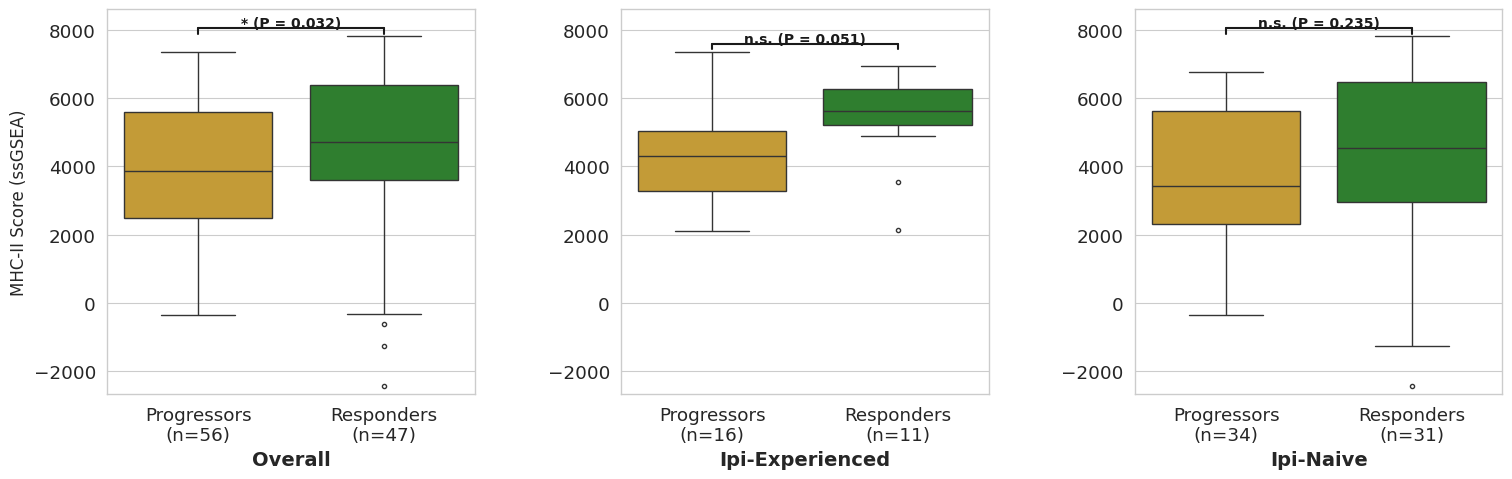

avatarsk10_42


/tmp/ipykernel_224275/3745059304.py:212: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


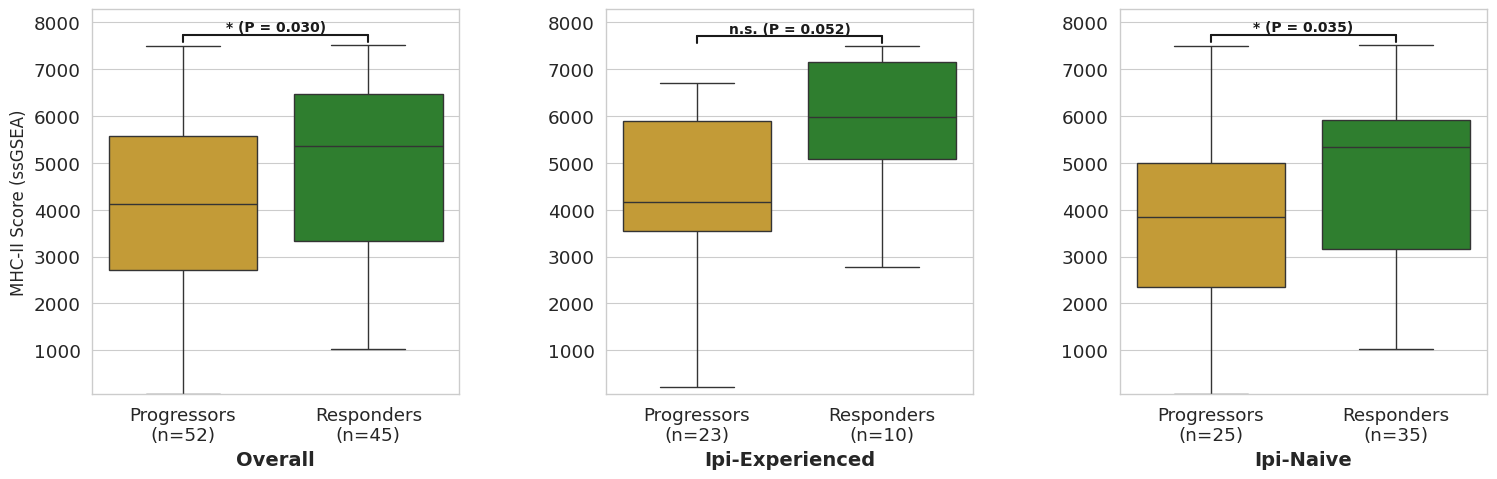

ctgan_42


/tmp/ipykernel_224275/3745059304.py:212: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


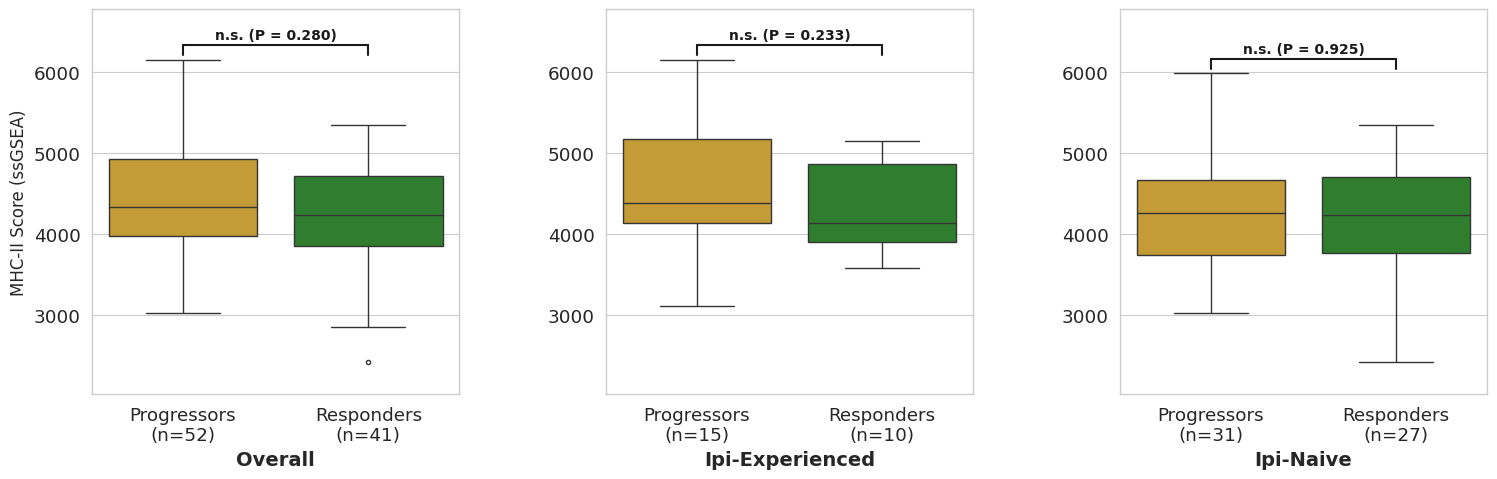

gaussiancopula_42


/tmp/ipykernel_224275/3745059304.py:212: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


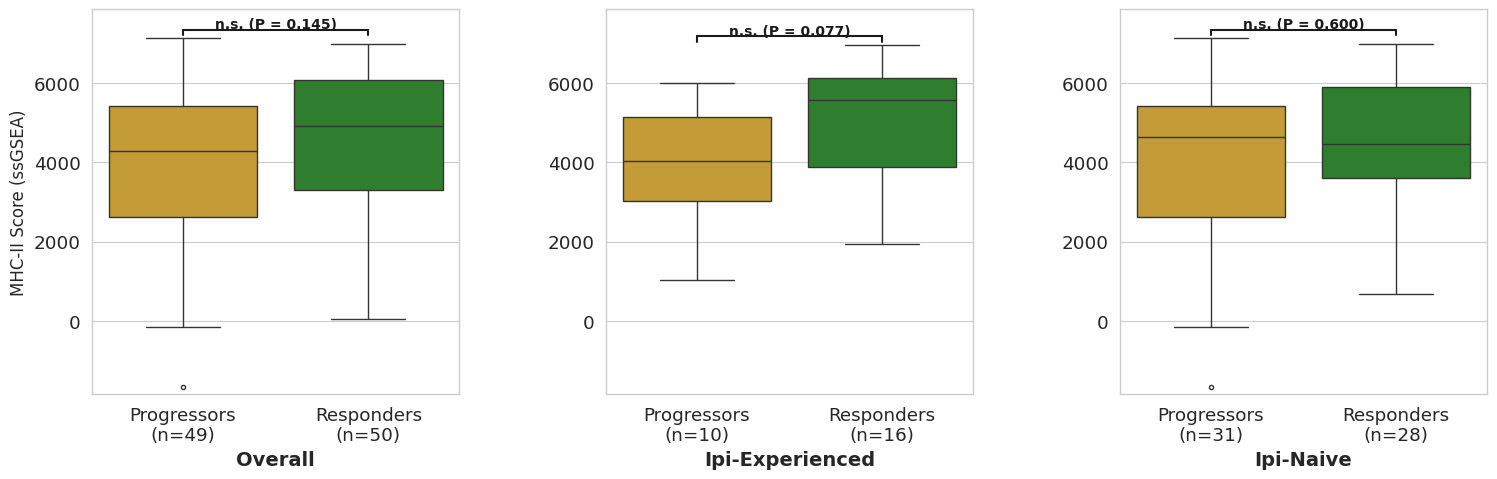

synthpop_42


/tmp/ipykernel_224275/3745059304.py:212: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


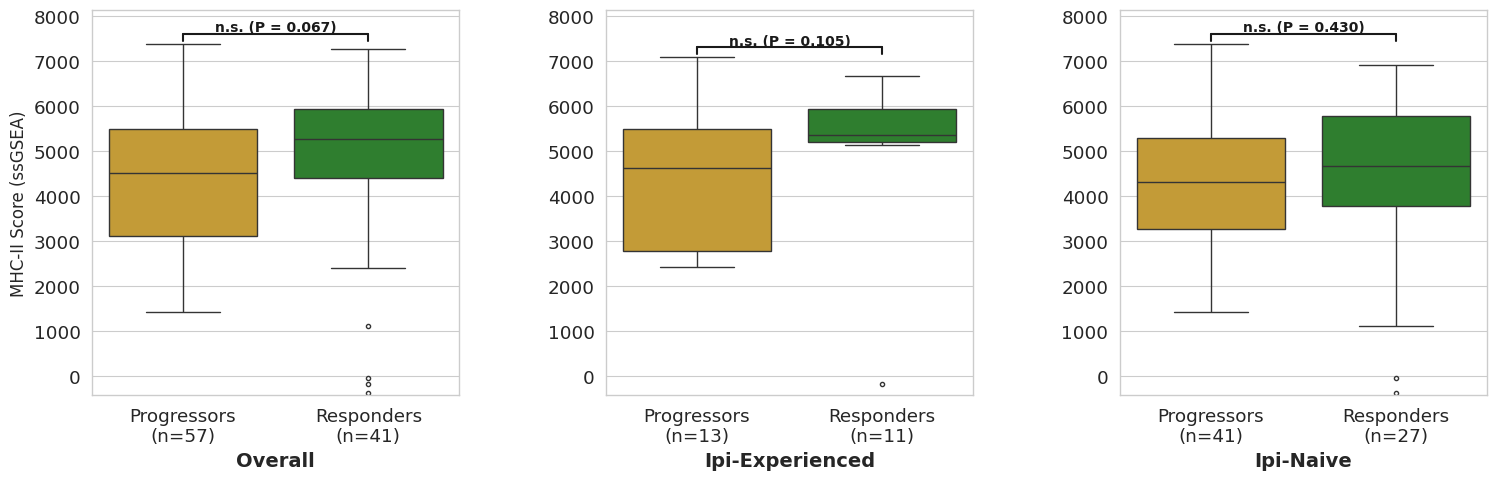

tvae_42


/tmp/ipykernel_224275/3745059304.py:212: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


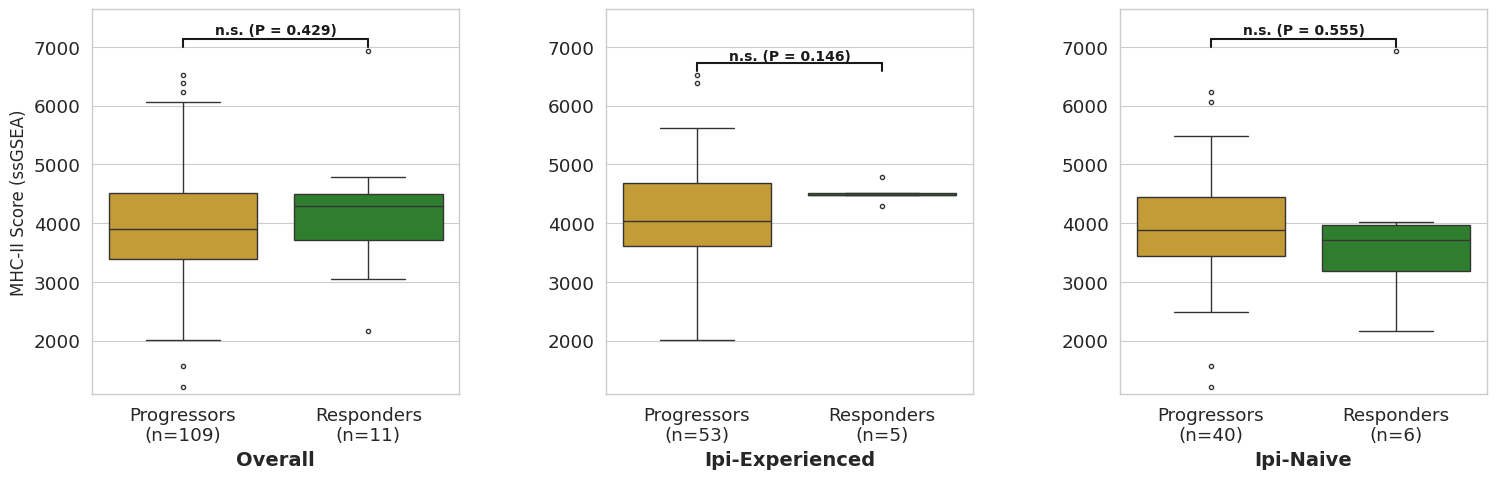

In [158]:
for tool, df in dataset_dict.items():
    print(tool)
    fig = MHC2_distribution(tool)